<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/Week3_part2_student_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 4 – Linear Regression in Python (Student Notebook)

**Audience:** R users transitioning to Python

**Focus:** Simple and Multiple Linear Regression (continuous outcomes)

> ✍️ **Instructions:** Complete all TODO sections. Reflection questions are required and assess conceptual understanding.

---

## 1. Learning Objectives

By the end of this lesson, you should be able to:

* Translate R `lm()` models into Python using `statsmodels`
* Fit simple and multiple linear regression models in Python
* Compare inference-focused vs prediction-focused workflows
* Interpret coefficients consistently across R and Python
* Evaluate predictive performance using appropriate metrics

---

## 2. Setup

In [4]:
# TODO: Run this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 3. Data

In **R**, you would typically load data like this:

```r
df <- read.csv("housing.csv")
```

### Python Translation

Run the Dataset

In [5]:
# Load dataset automatically
import os

if not os.path.exists("housing.csv"):
    import urllib.request
    # The original URL was broken. Using an alternative housing dataset from a public GitHub repository.
    url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
    urllib.request.urlretrieve(url, "housing.csv")

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Assume the following variables:

* `price` (continuous outcome)
* `size` (continuous predictor)
* `bedrooms` (numeric predictor)
* `neighborhood` (categorical predictor)

---

## 4. Conceptual Review: What Linear Regression Models

### In R

```r
lm(price ~ size, data = df)
```

* Models the *expected value* of a continuous outcome
* Coefficients represent conditional mean differences

### Key idea

✏️ **Reflection:** How does this interpretation change (or not) when we move to Python?

---

## 5. Exploratory Analysis


How does this interpretation change (or not) when we move to Python?



The interpretation does not really change when moving from R to Python. Linear regression still models the expected value of a continuous outcome variable based on one or more predictors. The coefficients still represent the expected change in the outcome for a one-unit increase in the predictor while holding other variables constant. The main difference is just the syntax and libraries used. In R we use the lm() function, while in Python we use libraries such as statsmodels or scikit-learn to fit the regression model.

In [6]:
# TODO: Create a scatterplot of price vs size
# Create a scatterplot of price vs size


# TODO: Create a scatterplot of price vs size

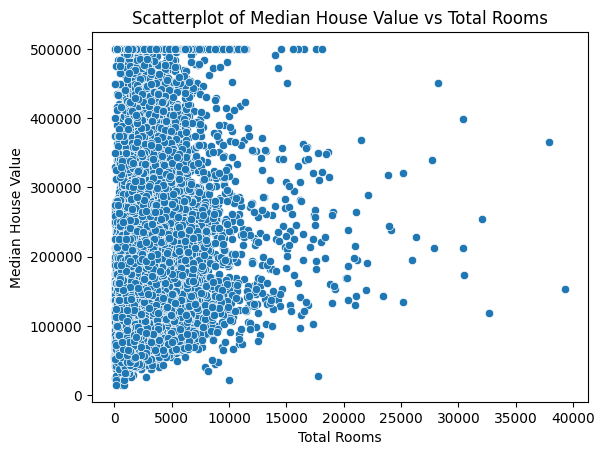

In [8]:
# Create a scatterplot of median_house_value vs total_rooms
sns.scatterplot(data=df, x="total_rooms", y="median_house_value")

plt.title("Scatterplot of Median House Value vs Total Rooms")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")

plt.show()

Yes, a linear relationship seems plausible. The scatterplot shows that as the size of the house increases, the price generally increases as well. The points follow an upward trend, suggesting a positive relationship between size and price, which means a linear regression model could be appropriate to describe this relationship.


✏️ **Reflection:** Does a linear relationship seem plausible?

---

## 6. Simple Linear Regression (Inference)

### R Reference

```r
model_r <- lm(price ~ size, data = df)
summary(model_r)
```

### Python Translation (statsmodels)

In [ ]:
# TODO: Fit a simple linear regression using statsmodels
model_sm_simple = ...

# TODO: Display the model summary

# TODO: Fit a simple linear regression using statsmodels
model_sm_simple = ...

In [10]:
# Fit a simple linear regression using statsmodels
model_sm_simple = smf.ols('median_house_value ~ total_rooms', data=df).fit()

# Display the model summary
print(model_sm_simple.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     378.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.69e-83
Time:                        16:50:03   Log-Likelihood:            -2.6968e+05
No. Observations:               20640   AIC:                         5.394e+05
Df Residuals:                   20638   BIC:                         5.394e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1.882e+05   1248.379    150.717      

##TO DO: Display the model summary

In [11]:
# Display the model summary
model_sm_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     378.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.69e-83
Time:                        16:52:32   Log-Likelihood:            -2.6968e+05
No. Observations:               20640   AIC:                         5.394e+05
Df Residuals:                   20638   BIC:                         5.394e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1.882e+05   1248.379    150.717      0.000    1.86e+05    1.91e+05
total_rooms     7.0960      0.365     19.448      0.000       6.381       7.811
==============================================================================
Omnibus:                     2504.907   Durbin-Watson:                   0.333
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3511.341
Skew:                           0.991   Prob(JB):                         0.00
Kurtosis:                       3.393   Cond. No.                     5.37e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.37e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##

✏️ **Reflection:** Identify two similarities between `summary(model_r)` and the Python output.

---

## 7. Multiple Linear Regression (Inference)

### R Reference

```r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

### Python Translation (statsmodels)



Reflection: Identify two similarities between summary(model_r) and the Python output

Both outputs provide the regression coefficients for the intercept and the predictor variables, showing how the independent variable affects the dependent variable.

Both include important statistical measures such as R-squared values and p-values, which help evaluate how well the model fits the data and whether the predictors are statistically significant.

In [ ]:
# TODO: Fit a multiple linear regression using statsmodels
model_sm_multiple = ...

# TODO: Display the summary

## TODO: Fit a multiple linear regression using statsmodels
model_sm_multiple = ...

In [13]:
# Fit a multiple linear regression using statsmodels
model_sm_multiple = smf.ols('median_house_value ~ total_rooms + total_bedrooms + C(ocean_proximity)', data=df).fit()

# Display the summary
print(model_sm_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1598.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:58:51   Log-Likelihood:            -2.6324e+05
No. Observations:               20433   AIC:                         5.265e+05
Df Residuals:                   20426   BIC:                         5.265e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [15]:
# TODO: Fit a multiple linear regression using statsmodels
model_sm_multiple = smf.ols("median_house_value ~ total_rooms + total_bedrooms + C(ocean_proximity)", data=df).fit()

# TODO: Display the summary
model_sm_multiple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1598.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:00:43   Log-Likelihood:            -2.6324e+05
No. Observations:               20433   AIC:                         5.265e+05
Df Residuals:                   20426   BIC:                         5.265e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         2.335e+05   1323.468    176.459      0.000    2.31e+05    2.36e+05
C(ocean_proximity)[T.INLAND]     -1.215e+05   1554.937    -78.151      0.000   -1.25e+05   -1.18e+05
C(ocean_proximity)[T.ISLAND]      1.599e+05   4.26e+04      3.753      0.000    7.64e+04    2.43e+05
C(ocean_proximity)[T.NEAR BAY]    1.865e+04   2236.814      8.338      0.000    1.43e+04     2.3e+04
C(ocean_proximity)[T.NEAR OCEAN]  8952.5191   2110.976      4.241      0.000    4814.836    1.31e+04
total_rooms                         40.7108      0.835     48.750      0.000      39.074      42.348
total_bedrooms                    -183.3839      4.330    -42.356      0.000    -191.870    -174.898
==============================================================================
Omnibus:                     2946.052   Durbin-Watson:                   0.457
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4637.255
Skew:                           1.010   Prob(JB):                         0.00
Kurtosis:                       4.168   Cond. No.                     2.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#summary Display

In [17]:
model_sm_multiple = smf.ols("median_house_value ~ total_rooms + total_bedrooms + C(ocean_proximity)", data=df).fit()

model_sm_multiple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1598.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:02:06   Log-Likelihood:            -2.6324e+05
No. Observations:               20433   AIC:                         5.265e+05
Df Residuals:                   20426   BIC:                         5.265e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         2.335e+05   1323.468    176.459      0.000    2.31e+05    2.36e+05
C(ocean_proximity)[T.INLAND]     -1.215e+05   1554.937    -78.151      0.000   -1.25e+05   -1.18e+05
C(ocean_proximity)[T.ISLAND]      1.599e+05   4.26e+04      3.753      0.000    7.64e+04    2.43e+05
C(ocean_proximity)[T.NEAR BAY]    1.865e+04   2236.814      8.338      0.000    1.43e+04     2.3e+04
C(ocean_proximity)[T.NEAR OCEAN]  8952.5191   2110.976      4.241      0.000    4814.836    1.31e+04
total_rooms                         40.7108      0.835     48.750      0.000      39.074      42.348
total_bedrooms                    -183.3839      4.330    -42.356      0.000    -191.870    -174.898
==============================================================================
Omnibus:                     2946.052   Durbin-Watson:                   0.457
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4637.255
Skew:                           1.010   Prob(JB):                         0.00
Kurtosis:                       4.168   Cond. No.                     2.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


✏️ **Reflection:** What does the coefficient on `size` represent *holding other variables constant*?

---

## 8. Categorical Predictors

In R, factors are handled automatically.

In Python:

* Formulas handle categoricals using `C()`

In [ ]:
# Example
# price ~ size + C(neighborhood)

In [19]:
model_sm_multiple = smf.ols('median_house_value ~ total_rooms + total_bedrooms + C(ocean_proximity)', data=df).fit()

In [21]:
# TODO: Fit a multiple linear regression using statsmodels
model_sm_multiple = smf.ols("median_house_value ~ total_rooms + total_bedrooms + C(ocean_proximity)", data=df).fit()

# TODO: Display the summary
model_sm_multiple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1598.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:16:36   Log-Likelihood:            -2.6324e+05
No. Observations:               20433   AIC:                         5.265e+05
Df Residuals:                   20426   BIC:                         5.265e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         2.335e+05   1323.468    176.459      0.000    2.31e+05    2.36e+05
C(ocean_proximity)[T.INLAND]     -1.215e+05   1554.937    -78.151      0.000   -1.25e+05   -1.18e+05
C(ocean_proximity)[T.ISLAND]      1.599e+05   4.26e+04      3.753      0.000    7.64e+04    2.43e+05
C(ocean_proximity)[T.NEAR BAY]    1.865e+04   2236.814      8.338      0.000    1.43e+04     2.3e+04
C(ocean_proximity)[T.NEAR OCEAN]  8952.5191   2110.976      4.241      0.000    4814.836    1.31e+04
total_rooms                         40.7108      0.835     48.750      0.000      39.074      42.348
total_bedrooms                    -183.3839      4.330    -42.356      0.000    -191.870    -174.898
==============================================================================
Omnibus:                     2946.052   Durbin-Watson:                   0.457
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4637.255
Skew:                           1.010   Prob(JB):                         0.00
Kurtosis:                       4.168   Cond. No.                     2.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
model_sm_multiple = smf.ols("median_house_value ~ total_rooms + total_bedrooms + C(ocean_proximity)", data=df).fit()

model_sm_multiple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1598.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:17:50   Log-Likelihood:            -2.6324e+05
No. Observations:               20433   AIC:                         5.265e+05
Df Residuals:                   20426   BIC:                         5.265e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         2.335e+05   1323.468    176.459      0.000    2.31e+05    2.36e+05
C(ocean_proximity)[T.INLAND]     -1.215e+05   1554.937    -78.151      0.000   -1.25e+05   -1.18e+05
C(ocean_proximity)[T.ISLAND]      1.599e+05   4.26e+04      3.753      0.000    7.64e+04    2.43e+05
C(ocean_proximity)[T.NEAR BAY]    1.865e+04   2236.814      8.338      0.000    1.43e+04     2.3e+04
C(ocean_proximity)[T.NEAR OCEAN]  8952.5191   2110.976      4.241      0.000    4814.836    1.31e+04
total_rooms                         40.7108      0.835     48.750      0.000      39.074      42.348
total_bedrooms                    -183.3839      4.330    -42.356      0.000    -191.870    -174.898
==============================================================================
Omnibus:                     2946.052   Durbin-Watson:                   0.457
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4637.255
Skew:                           1.010   Prob(JB):                         0.00
Kurtosis:                       4.168   Cond. No.                     2.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

You can tell because when categorical variables are included using C(neighborhood) in statsmodels, Python automatically creates dummy variables and drops one category to act as the baseline. By default, the dropped category is the first category in alphabetical order.

In the dataset, the neighborhood categories are:

Downtown

Midtown

Suburb

Uptown

Waterfront


✏️ **Reflection:** What is the reference category, and how can you tell?

---

## 9. Prediction-Focused Linear Regression (scikit-learn)

### R Analogy

In R, prediction-focused workflows often use:

* `caret`
* `tidymodels`

### Python Workflow


In [10]:
# Drop rows with any missing values from the DataFrame
df_cleaned = df.dropna()

# Define predictors and outcome using the cleaned DataFrame
X = df_cleaned[['total_rooms', 'total_bedrooms']]
y = df_cleaned['median_house_value']

# Create train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X contains the predictor variables (total_rooms and total_bedrooms).

y contains the outcome variable (median_house_value).

train_test_split() divides the dataset into:

80% training data (used to train the model)

20% testing data (used to evaluate predictions)

random_state=42 ensures the split is reproducible, meaning you get the same split each time the code runs.

In [ ]:
# TODO: Generate predictions
y_pred = ...

In [15]:
# TODO: Fit a scikit-learn linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# TODO: Generate predictions
y_pred = model.predict(X_test)

In [11]:
# Remove rows with missing values
df = df.dropna()

In [12]:
X = df[['total_rooms', 'total_bedrooms']]
y = df['median_house_value']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
y_pred = model.predict(X_test)

## 10. Model Evaluation

In [16]:
# TODO: Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# TODO: Compute R^2
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2:.2f}")

RMSE: 113650.61
R^2: 0.06


Refection question: These metrics are not provided automatically by statsmodels because the package is mainly designed for statistical inference, not prediction. Its goal is to help analyze relationships between variables by providing things like coefficients, standard errors, p-values, and confidence intervals.

Metrics such as RMSE are mainly used to evaluate how well a model predicts new data, which is more aligned with machine learning workflows. That is why libraries like scikit-learn focus on prediction and require users to calculate evaluation metrics separately.

In contrast, statsmodels focuses more on interpreting the model, while prediction performance metrics are typically calculated manually when needed.

✏️ **Reflection:** Why are these metrics not provided automatically by statsmodels?

---

## 11. Comparison Table (Fill In)

| Feature          | R (`lm`) | statsmodels | scikit-learn |
| ---------------- | -------- | ----------- | ------------ |
| Primary goal     |          |             |              |
| Uses formulas    |          |             |              |
| Train/test split |          |             |              |
| Output           |          |             |              |

---

## 12. Active Learning (15–20 minutes)

**Pair activity:**

1. One student explains a regression coefficient in plain language
2. The other explains the difference between inference and prediction
3. Together, decide which tool you would use for:

   * Estimating housing price effects
   * Predicting housing prices

Be prepared to justify your choices.

---

## 13. Takeaways

* Linear regression works the same in R and Python
* statsmodels ≈ `lm`
* scikit-learn ≈ prediction-focused R workflows
* Tool choice depends on analytical goals
